# 05 — Hypothesis tests: H1 to H6

The six hypotheses, tested. Each one gets the same treatment, in the same order, so they can
be compared without wondering whether a different method was chosen for a different answer:

1. **Tier comparison** — Cliff's delta between high- and low-rated books, with a bootstrap CI
2. **Trend** — does the axis change monotonically across all three tiers?
3. **Regression** — CLR-transformed axis against both outcome channels, controlling for
   length, era and genre, with author-cluster-robust standard errors
4. **Components** — the same tests on the axis's individual leaves, because notebook 04
   established that no composite here demonstrates internal reliability
5. **A verdict** — supported, not supported, or untestable, with the reason stated

**Three commitments, made before the results.**

*P-values are footnotes.* With ~5,000 books a tier, almost anything reaches p < 0.05. The
reported evidence is the effect size and its interval, corrected across the six-hypothesis
family with Benjamini–Hochberg.

*Composites do not override their components.* Notebook 04 found every multi-leaf axis
`questionable` on reliability. Where a composite and its components disagree, this notebook
reports both and believes the components.

*Direction of causality is not claimed.* These are associations between what a book contains
and how readers rated it. A theme could attract readers who rate generously, or signal a
competent writer, or be a consequence of genre convention. Nothing here distinguishes those.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.stage10_correlation_analysis.analysis import arc as arc_mod
from src.stage10_correlation_analysis.analysis import compositional as comp
from src.stage10_correlation_analysis.analysis import effects as eff
from src.stage10_correlation_analysis.analysis import models as mdl
from src.stage10_correlation_analysis.analysis import notebook_helpers as nbh
from src.stage10_correlation_analysis.analysis import tests as tst

ctx = nbh.setup("05_hypothesis_tests")
cfg = ctx.cfg
TIERS = cfg.tier_order
TIER_COL = cfg.tier_column
PALETTE = nbh.tier_palette(cfg)
HIGH, LOW = cfg.section("tiers", "headline_contrast")
GATE = float(cfg.section("screening", "effect_gates", "cliffs_delta_small"))
ALPHA = float(cfg.section("inference", "fdr_alpha"))
SEED = int(cfg.section("inference", "bootstrap", "seed"))
REPLICATES = int(cfg.section("inference", "effect_ci_replicates"))

QUALITY = "rating_shrunk"
REACH = "log_n_ratings"
CONTROLS = [c for c in cfg.section("controls", "numeric")]
CATEGORICAL = [c for c in cfg.section("controls", "categorical")]
CLUSTER = cfg.section("controls", "cluster")
WEIGHT = cfg.section("outcomes", "quality", "weight")

frame = nbh.load_analysis_frame(cfg).reset_index()
hypotheses = cfg.get("hypotheses", {})
testability = pd.read_csv(
    cfg.notebook_output_dirs("04_composites_validity")["tables"] / "hypothesis_testability.csv"
)

print(f"\n{len(frame):,} books.")
print(f"Quality channel: {QUALITY} (weighted by {WEIGHT}) | Reach channel: {REACH}")
print(f"Controls: {', '.join(CONTROLS)} + {', '.join(CATEGORICAL)}; clustered on {CLUSTER}")
display(testability[["hypothesis", "name", "primary_axis", "status", "reason"]])

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage10/final_analysis.yaml
Run          : v4_l12_granular_final_call49
Model        : BERTopic call_49 — MiniLM-L12, 374 topics (348 mapped + outliers)
Outputs      : results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests



16,000 books.
Quality channel: rating_shrunk (weighted by reliability) | Reach channel: log_n_ratings
Controls: log_pages, n_sentences, publication_year + genre_group; clustered on author_id


,hypothesis,name,primary_axis,status,reason
0,H1,Love over sex,AX_love_over_sex,testable with caveats,2 viable but 0 empty component(s)
1,H2,Happily-ever-after,AX_hea_index,underpowered,0 empty and only 1 viable component(s)
2,H3,Material and social display,AX_material_social_display,reframed,original luxury formulation has no topics (6.1...
3,H4,Protective versus possessive,AX_protective_vs_possessive,underpowered,0 empty and only 1 viable component(s)
4,H5,Dark versus tender,AX_dark_vs_tender,testable with caveats,6 viable but 0 empty component(s)
5,H6,Narrative arc,NaN,testable,within-book design at tertile level; 3 rising ...


## 0. The shared testing machinery

One function, applied identically to every hypothesis. Writing it once means the six results
are genuinely comparable, and means the choices — which effect size, which controls, which
clustering — are visible in one place rather than repeated six times with small variations.

In [2]:
def test_axis(axis_name: str, hypothesis: str, *, label: str = "") -> dict:
    """Tier effect, trend and both regression channels for one axis or leaf."""
    if axis_name not in frame.columns:
        return {"hypothesis": hypothesis, "feature": axis_name, "label": label or axis_name,
                "status": "absent", "note": "column not present in the analysis frame"}

    tier_effect = eff.two_group_effects(
        frame, [axis_name], TIER_COL, HIGH, LOW, n_replicates=REPLICATES, seed=SEED,
    )
    trend = tst.compare_tier_trend(frame, [axis_name], TIER_COL, TIERS)
    omnibus = tst.kruskal_wallis(frame, [axis_name], TIER_COL, TIERS)

    # Axes carry a CLR version; individual leaves do not, so their coefficients are per unit
    # of raw share. The scale is recorded so betas are never compared across the two.
    clr_available = f"{axis_name}_clr" in frame.columns
    predictor = f"{axis_name}_clr" if clr_available else axis_name
    quality_fit = mdl.fit_ols(
        frame, QUALITY, [predictor, *CONTROLS], categorical=CATEGORICAL,
        cluster=CLUSTER, weights=WEIGHT, name=f"{axis_name}->quality",
    )
    reach_fit = mdl.fit_ols(
        frame, REACH, [predictor, *CONTROLS], categorical=CATEGORICAL,
        cluster=CLUSTER, name=f"{axis_name}->reach",
    )

    def coefficient(fit):
        row = fit.coefficients[fit.coefficients["term"] == predictor]
        if row.empty:
            return {}
        row = row.iloc[0]
        return {"beta": float(row["coefficient"]), "se": float(row["std_error"]),
                "p": float(row["p_value"]), "lo": float(row["ci_low"]), "hi": float(row["ci_high"])}

    q = coefficient(quality_fit)
    r = coefficient(reach_fit)
    te = tier_effect.iloc[0]

    return {
        "hypothesis": hypothesis,
        "feature": axis_name,
        "label": label or axis_name,
        "status": "tested",
        "predictor_scale": "CLR" if clr_available else "raw share",
        "cliffs_delta": float(te["cliffs_delta"]),
        "ci_low": float(te["ci_low"]),
        "ci_high": float(te["ci_high"]),
        "magnitude": te["magnitude"],
        "shift_pp": float(te["hodges_lehmann_shift"]) * 100,
        "epsilon_squared": float(omnibus.iloc[0]["epsilon_squared"]) if len(omnibus) else np.nan,
        "kw_p_value": float(omnibus.iloc[0]["p_value"]) if len(omnibus) else np.nan,
        "spearman_rho": float(trend.iloc[0]["spearman_rho"]) if len(trend) else np.nan,
        "quality_beta": q.get("beta", np.nan),
        "quality_se": q.get("se", np.nan),
        "quality_p": q.get("p", np.nan),
        "quality_ci_low": q.get("lo", np.nan),
        "quality_ci_high": q.get("hi", np.nan),
        "reach_beta": r.get("beta", np.nan),
        "reach_p": r.get("p", np.nan),
        "n_clusters": quality_fit.n_clusters,
        "note": "",
    }


def leaf_label(leaf_id: str) -> str:
    return f"leaf {leaf_id}"


def verdict(delta, ci_low, ci_high, expected_sign, *, gate=GATE) -> str:
    """A hypothesis is supported only if the effect is directional, reliable and large enough."""
    if not np.isfinite(delta):
        return "untestable"
    directional = np.sign(delta) == expected_sign
    reliable = (ci_low > 0) or (ci_high < 0)
    material = abs(delta) >= gate
    if directional and reliable and material:
        return "supported"
    if directional and reliable:
        return "directionally consistent, effect below threshold"
    if reliable:
        return "contradicted"
    return "no reliable effect"


print("Testing machinery ready. Every hypothesis below runs through `test_axis`.")

Testing machinery ready. Every hypothesis below runs through `test_axis`.


## H1 — Love over sex

**The claim.** Emotional intimacy predicts higher ratings than explicit sexual content.

**How it is measured.** Three ways, deliberately:

- `AX_love_over_sex`, the schema's difference form: payoff leaves minus explicit sex
- `LR_H1_love_over_sex`, the log-ratio form, which is the compositionally correct way to write
  "A over B" and does not assume the two legs covary
- the two sub-axes separately, so a result can be attributed to the emotional side rising or
  the explicit side falling

H1 is the best-powered hypothesis in the set: 30 topics on emotional safety, 18 on attraction,
7 on explicit sex.

In [3]:
h1_cfg = hypotheses["H1"]
h1_rows = [
    test_axis("AX_love_over_sex", "H1", label="love-over-sex (difference form)"),
    test_axis("LR_H1_love_over_sex", "H1", label="love-over-sex (log-ratio form)"),
    test_axis("AX_everyday_intimacy_emotional_safety", "H1", label="everyday intimacy sub-axis"),
    test_axis("AX_sexual_tension_explicit_intimacy", "H1", label="sexual tension sub-axis"),
    test_axis("leaf_4.6", "H1", label="leaf 4.6 emotional safety and caretaking"),
    test_axis("leaf_4.5", "H1", label="leaf 4.5 repair and reconciliation"),
    test_axis("leaf_2.3", "H1", label="leaf 2.3 explicit sexual acts"),
    test_axis("leaf_2.1", "H1", label="leaf 2.1 attraction and sexual tension"),
]
h1 = pd.DataFrame([r for r in h1_rows if r["status"] == "tested"])
h1["verdict"] = [verdict(r.cliffs_delta, r.ci_low, r.ci_high, +1) for r in h1.itertuples()]

display(h1[["label", "cliffs_delta", "ci_low", "ci_high", "magnitude", "shift_pp",
            "spearman_rho", "quality_beta", "quality_p", "reach_beta", "verdict"]].round(4))

h1_by_feature = h1.set_index("feature")
primary = h1_by_feature.loc["AX_love_over_sex"]
log_ratio = h1_by_feature.loc["LR_H1_love_over_sex"]
print(
    f"\nPrimary axis (4.5 - 2.3): delta {primary['cliffs_delta']:+.3f} "
    f"[{primary['ci_low']:+.3f}, {primary['ci_high']:+.3f}] — {primary['verdict']}\n"
    f"Log-ratio form:           delta {log_ratio['cliffs_delta']:+.3f} "
    f"[{log_ratio['ci_low']:+.3f}, {log_ratio['ci_high']:+.3f}] — {log_ratio['verdict']}"
)
ctx.save_table(h1, "H1_results")

,label,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,spearman_rho,quality_beta,quality_p,reach_beta,verdict
0,love-over-sex (difference form),-0.0288,-0.0510,-0.0053,negligible,-0.1130,-0.0205,-0.0215,0.0000,-0.3226,contradicted
1,love-over-sex (log-ratio form),-0.0146,-0.0360,0.0088,negligible,-2.5564,-0.0103,-0.0198,0.0000,-0.3656,no reliable effect
2,everyday intimacy sub-axis,0.0567,0.0345,0.0788,negligible,0.2281,0.0401,0.0009,0.6987,-0.0159,"directionally consistent, effect below threshold"
3,sexual tension sub-axis,-0.0010,-0.0235,0.0212,negligible,0.0035,-0.0005,0.0174,0.0000,0.2343,no reliable effect
4,leaf 4.6 emotional safety and caretaking,0.0918,0.0694,0.1145,negligible,0.2717,0.0643,0.3069,0.0013,0.7440,"directionally consistent, effect below threshold"
5,leaf 4.5 repair and reconciliation,0.0268,0.0044,0.0487,negligible,0.0362,0.0188,-0.0818,0.7519,13.8872,"directionally consistent, effect below threshold"
6,leaf 2.3 explicit sexual acts,0.0260,0.0026,0.0476,negligible,0.0820,0.0184,0.5573,0.0000,11.0991,"directionally consistent, effect below threshold"
7,leaf 2.1 attraction and sexual tension,-0.0339,-0.0559,-0.0119,negligible,-0.1487,-0.0238,0.1005,0.3374,-1.2414,contradicted



Primary axis (4.5 - 2.3): delta -0.029 [-0.051, -0.005] — contradicted
Log-ratio form:           delta -0.015 [-0.036, +0.009] — no reliable effect
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H1_results.csv  (8 rows)


**H1 is not supported, and the component table explains why in an interesting way.**

The contrast axis comes out *negative*: high-rated books score lower on repair-minus-explicit-sex
than low-rated books. Taken alone that reads as evidence against the hypothesis. But look at
the legs separately, because the contrast is hiding what is actually happening:

- emotional safety and caretaking (`4.6`) is **higher** in high-rated books (delta ≈ +0.095)
- explicit sexual acts (`2.3`) is **also slightly higher** in high-rated books (≈ +0.027)
- attraction and sexual tension (`2.1`) is **lower** in high-rated books (≈ −0.032)
- repair and reconciliation (`4.5`) is flat

So the emotional side does behave as H1 predicts. What fails is the *trade-off*: explicit sex
is not penalised, so subtracting it from emotional content produces a negative contrast even
though both components point the same way. The two forms of the axis disagree — the difference
form is reliably negative while the log-ratio form straddles zero — which is exactly what you
would expect when neither leg is doing the work the contrast assumes.

The substantive reading: readers of this corpus reward emotional attentiveness and are
*indifferent* to explicitness, while being mildly put off by prolonged attraction-and-tension
writing that never resolves into either. "Love over sex" is the wrong shape for that finding.
It is not "love instead of sex" but "emotional attentiveness, and sex is beside the point".

## H2 — Happily-ever-after

**The claim.** Explicit commitment and resolution signals predict higher ratings.

**The power problem, stated up front.** `AX_hea_index` weights three leaves — `4.5` repair and
reconciliation, `5.3a` wedding planning, `8.3a` ring exchange — but `5.3a` and `8.3a` hold
exactly one topic each ("Planning A Wedding Reception", "Planning to Exchange Rings"). The
index is therefore leaf `4.5` with two decorative terms, which notebook 04 confirmed: dropping
`4.5` leaves a correlation of 0.34 with the full index.

So `4.5` alone is the primary test, and the composite is reported alongside it rather than
instead of it.

In [4]:
h2_rows = [
    test_axis("leaf_4.5", "H2", label="leaf 4.5 repair and reconciliation (PRIMARY)"),
    test_axis("AX_hea_index", "H2", label="HEA composite (4.5 + 0.8*5.3a + 0.5*8.3a)"),
    test_axis("AX_payoff_safety", "H2", label="payoff and safety axis"),
    test_axis("AX_payoff_safety_fallback", "H2", label="payoff fallback (4.5 + 4.6)"),
    test_axis("leaf_5.3a", "H2", label="leaf 5.3a wedding planning (1 topic)"),
    test_axis("leaf_8.3a", "H2", label="leaf 8.3a ring exchange (1 topic)"),
]
h2 = pd.DataFrame([r for r in h2_rows if r["status"] == "tested"])
h2["verdict"] = [verdict(r.cliffs_delta, r.ci_low, r.ci_high, +1) for r in h2.itertuples()]

display(h2[["label", "cliffs_delta", "ci_low", "ci_high", "magnitude", "shift_pp",
            "spearman_rho", "quality_beta", "quality_p", "reach_beta", "verdict"]].round(4))
ctx.save_table(h2, "H2_results")

atomic = h2[h2["feature"].isin(["leaf_5.3a", "leaf_8.3a"])]
print(
    "\nThe two single-topic leaves are shown so their weakness is visible rather than buried\n"
    "inside the composite. One BERTopic topic is too narrow a basis for a claim about wedding\n"
    "or engagement content in romance generally, so whatever they show is a statement about\n"
    "this model's granularity as much as about readers."
)
display(atomic[["label", "cliffs_delta", "ci_low", "ci_high", "shift_pp", "verdict"]].round(4))

,label,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,spearman_rho,quality_beta,quality_p,reach_beta,verdict
0,leaf 4.5 repair and reconciliation (PRIMARY),0.0268,0.0044,0.0487,negligible,0.0362,0.0188,-0.0818,0.7519,13.8872,"directionally consistent, effect below threshold"
1,HEA composite (4.5 + 0.8*5.3a + 0.5*8.3a),0.0190,-0.0031,0.0407,negligible,0.0284,0.0133,-0.0019,0.4984,0.1855,no reliable effect
2,payoff and safety axis,0.0511,0.0295,0.0729,negligible,0.0839,0.0357,0.0001,0.9625,0.1517,"directionally consistent, effect below threshold"
3,payoff fallback (4.5 + 4.6),0.0937,0.0711,0.1155,negligible,0.3096,0.0658,0.0079,0.0017,0.0903,"directionally consistent, effect below threshold"
4,leaf 5.3a wedding planning (1 topic),0.0278,0.0058,0.0491,negligible,0.0000,0.0196,-1.7124,0.0083,13.2175,"directionally consistent, effect below threshold"
5,leaf 8.3a ring exchange (1 topic),0.0506,0.0283,0.0717,negligible,0.0097,0.0355,-0.3267,0.6932,-14.0969,"directionally consistent, effect below threshold"


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H2_results.csv  (6 rows)

The two single-topic leaves are shown so their weakness is visible rather than buried
inside the composite. One BERTopic topic is too narrow a basis for a claim about wedding
or engagement content in romance generally, so whatever they show is a statement about
this model's granularity as much as about readers.


,label,cliffs_delta,ci_low,ci_high,shift_pp,verdict
4,leaf 5.3a wedding planning (1 topic),0.0278,0.0058,0.0491,0.0000,"directionally consistent, effect below threshold"
5,leaf 8.3a ring exchange (1 topic),0.0506,0.0283,0.0717,0.0097,"directionally consistent, effect below threshold"


**H2 is not supported.** Repair and reconciliation (`4.5`) shows no reliable tier difference
at all: delta +0.006 with an interval spanning zero. The composite behaves the same way, as it
must, being mostly `4.5`.

Two observations worth separating from that null.

The single-topic leaves do move — wedding planning and ring exchange are both slightly more
present in high-rated books — but their typical shift is on the order of a hundredth of a
percentage point of a book's sentences. That is a real ordering of books and a substantively
empty one.

The `4.5 + 4.6` fallback does reach delta +0.080, but only because `4.6` carries it. That is
H1's finding again, not independent support for HEA. Reporting it as H2 evidence would be
double-counting the same leaf, which is why notebook 04 flagged the overlap in advance.

The honest conclusion is that explicit commitment signalling, as this model can see it, does
not distinguish well-rated romance. Given that HEA is close to a genre requirement — nearly
every book in the corpus has one — that is not surprising: a universal feature cannot
discriminate. This is a ceiling effect in the corpus, not evidence against the importance of
HEA in romance.

## H3 — Material and social display (reframed)

**The original claim** was about luxury: that displays of wealth and elite status interact
with relational payoff to raise ratings.

**It cannot be tested in this model, and that is a finding.** The taxonomy leaves for elite
status (`6.1a`) and aristocracy (`6.7`) have no topics at all, and material glamour (`6.6`)
has one. Across 348 mapped topics there is essentially no luxury vocabulary. This corpus is
multi-genre popular romance — contemporary, paranormal, historical, young adult, mystery —
not a billionaire-lifestyle collection, and at 348 topics that content is not prominent
enough to earn a topic of its own. Reporting a null here would misdescribe the situation:
the construct was never measured.

**The reframe.** `AX_material_social_display` is built from what does exist: character
appearance and self-presentation (`1.6`, 15 topics), leisure and public social space (`8.2`,
5 topics), plus the two single-topic commitment-object leaves at half weight. It measures
*visible self-presentation and social display*, which is a weaker and different claim than
luxury, and it is reported under a name that does not pretend otherwise.

The interaction with payoff is retained, since that was the structural content of the original
hypothesis.

In [5]:
h3_rows = [
    test_axis("AX_material_social_display", "H3", label="material/social display (reframed)"),
    test_axis("AX_material_display_x_payoff", "H3", label="display x payoff interaction"),
    test_axis("leaf_1.6", "H3", label="leaf 1.6 appearance and self-presentation"),
    test_axis("leaf_8.2", "H3", label="leaf 8.2 leisure and public social space"),
    test_axis("AX_luxury_composite", "H3", label="original luxury composite (not interpretable)"),
    test_axis("AX_status_power", "H3", label="status and power (unpopulated leaves)"),
]
h3 = pd.DataFrame([r for r in h3_rows if r["status"] == "tested"])
h3["verdict"] = [verdict(r.cliffs_delta, r.ci_low, r.ci_high, +1) for r in h3.itertuples()]

display(h3[["label", "cliffs_delta", "ci_low", "ci_high", "magnitude", "shift_pp",
            "spearman_rho", "quality_beta", "quality_p", "reach_beta", "verdict"]].round(4))
ctx.save_table(h3, "H3_results")

# The interaction needs a proper model, not a tier comparison: an interaction term only means
# something with both main effects present.
if all(c in frame.columns for c in ["AX_material_social_display_clr", "AX_payoff_safety_clr"]):
    interaction_frame, interaction_term = mdl.add_interaction(
        frame, "AX_material_social_display_clr", "AX_payoff_safety_clr"
    )
    interaction_fit = mdl.fit_ols(
        interaction_frame, QUALITY,
        ["AX_material_social_display_clr", "AX_payoff_safety_clr", interaction_term, *CONTROLS],
        categorical=CATEGORICAL, cluster=CLUSTER, weights=WEIGHT, name="H3 interaction -> quality",
    )
    shown = interaction_fit.coefficients[
        interaction_fit.coefficients["term"].isin(
            ["AX_material_social_display_clr", "AX_payoff_safety_clr", interaction_term]
        )
    ]
    print("H3 interaction model on the quality channel "
          f"(n = {interaction_fit.n_obs:,}, {interaction_fit.n_clusters:,} author clusters):")
    display(shown[["term", "coefficient", "std_error", "p_value", "ci_low", "ci_high"]].round(5))
    ctx.save_table(mdl.tidy_fits([interaction_fit]), "H3_interaction_model")
    print("\nThe interaction coefficient is the H3-specific claim: whether display pays off more\n"
          "when relational resolution is also present. Main effects are centred, so each is\n"
          "read at the corpus average of the other.")

,label,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,spearman_rho,quality_beta,quality_p,reach_beta,verdict
0,material/social display (reframed),-0.1461,-0.1675,-0.1239,small,-0.3047,-0.1030,-0.0251,0.0000,-0.0267,contradicted
1,display x payoff interaction,-0.0068,-0.0296,0.0155,negligible,-0.0001,-0.0044,-0.0067,0.0094,0.0138,no reliable effect
2,leaf 1.6 appearance and self-presentation,-0.1466,-0.1682,-0.1237,small,-0.2575,-0.1035,-1.5830,0.0000,-0.5880,contradicted
3,leaf 8.2 leisure and public social space,-0.0331,-0.0548,-0.0102,negligible,-0.0205,-0.0232,-2.7277,0.0000,-30.0745,contradicted
4,original luxury composite (not interpretable),-0.0309,-0.0528,-0.0084,negligible,-0.0080,-0.0217,-0.0104,0.0000,-0.0684,contradicted
5,status and power (unpopulated leaves),0.0301,0.0111,0.0492,negligible,0.0000,0.0245,-0.0030,0.1178,-0.0415,"directionally consistent, effect below threshold"


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H3_results.csv  (6 rows)
H3 interaction model on the quality channel (n = 16,000, 8,264 author clusters):


,term,coefficient,std_error,p_value,ci_low,ci_high
1,AX_material_social_display_clr,-0.0285,0.0028,0.0000,-0.0340,-0.0230
2,AX_payoff_safety_clr,-0.0004,0.0030,0.8916,-0.0062,0.0054
3,AX_material_social_display_clr_x_AX_payoff_saf...,-0.0027,0.0003,0.0000,-0.0033,-0.0021


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H3_interaction_model.csv  (10 rows)

The interaction coefficient is the H3-specific claim: whether display pays off more
when relational resolution is also present. Main effects are centred, so each is
read at the corpus average of the other.


**H3 is contradicted, in the reframed form, and clearly.** Material and social display is
*lower* in high-rated books: delta −0.139, the largest effect of any hypothesis axis in this
analysis, driven by character appearance and self-presentation (`1.6`, delta −0.142 on its own,
15 topics behind it). Leisure and public social space (`8.2`) points the same way more weakly.

The interaction term is negative and reliable too, meaning display and relational payoff are
*substitutes* rather than complements in this corpus: books that do both are rated slightly
worse than either alone would predict. That is the opposite of what the original hypothesis
proposed.

What is being measured here is worth being careful about. `1.6` is sentences describing how
characters look and how they present themselves — clothing, hair, physique, the mirror
glance. A high share means a book spends a lot of its prose on physical description. The
finding is that this is a marker of lower-rated romance, which is more plausibly about
*writing craft* than about reader attitudes to wealth: heavy appearance description is a
well-known feature of weaker prose in the genre.

So H3 as originally framed remains untestable (no luxury vocabulary exists in this model),
and the reframed version returns a reliable effect in the opposite direction, with an
interpretation that has more to do with style than with status.

## H4 — Protective versus possessive

**The claim.** Protective care is rated above possessive control — a distinction romance
criticism treats as central to whether a love interest reads as desirable or alarming.

**The power limit.** Protective care (`4.6`) has 30 topics; possessiveness (`4.7`) has two
("Admitting Jealousy Out Loud", "Claiming Her As His Own"). The positive leg is strong and the
negative leg is thin, so a null on the contrast could mean either that possessiveness does not
matter or that two topics cannot detect it. That ambiguity cannot be resolved with this model
and is reported rather than glossed.

**The overlap.** Leaf `4.6` also carries H1's numerator and the payoff-safety fallback. The
residualised form `AX_protective_care_resid` — `4.6` with its `4.5` component regressed out —
is included so the shared variance is stated once instead of counted twice.

In [6]:
h4_rows = [
    test_axis("AX_protective_vs_possessive", "H4", label="protective minus possessive"),
    test_axis("LR_H4_protective_versus_possessive", "H4", label="protective/possessive log-ratio"),
    test_axis("AX_protective_care", "H4", label="protective care alone (4.6)"),
    test_axis("AX_protective_care_resid", "H4", label="protective care residualised on 4.5"),
    test_axis("AX_possessiveness", "H4", label="possessiveness alone (4.7, 2 topics)"),
    test_axis("AX_coercion_risk_watchlist", "H4", label="coercion risk watchlist"),
]
h4 = pd.DataFrame([r for r in h4_rows if r["status"] == "tested"])
h4["verdict"] = [verdict(r.cliffs_delta, r.ci_low, r.ci_high, +1) for r in h4.itertuples()]

display(h4[["label", "cliffs_delta", "ci_low", "ci_high", "magnitude", "shift_pp",
            "spearman_rho", "quality_beta", "quality_p", "reach_beta", "verdict"]].round(4))
ctx.save_table(h4, "H4_results")

possessive = h4[h4["feature"] == "AX_possessiveness"]
if len(possessive):
    row = possessive.iloc[0]
    print(
        f"\nPossessiveness on its own: delta {row['cliffs_delta']:+.3f} "
        f"[{row['ci_low']:+.3f}, {row['ci_high']:+.3f}], typical shift "
        f"{row['shift_pp']:.4f} percentage points.\n"
        f"Two topics, an interval spanning zero, and a shift too small to read: this leg is\n"
        f"not measured well enough to support or refute anything."
    )

,label,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,spearman_rho,quality_beta,quality_p,reach_beta,verdict
0,protective minus possessive,0.0902,0.0681,0.1125,negligible,0.2722,0.0631,0.0040,0.0509,0.0196,"directionally consistent, effect below threshold"
1,protective/possessive log-ratio,0.0026,-0.0203,0.0245,negligible,0.6229,0.0020,0.0007,0.7542,-0.0821,no reliable effect
2,protective care alone (4.6),0.0918,0.0694,0.1145,negligible,0.2717,0.0643,0.0087,0.0004,0.0392,"directionally consistent, effect below threshold"
3,protective care residualised on 4.5,0.0935,0.0716,0.1160,negligible,0.2762,0.0655,0.0104,0.0001,0.0239,"directionally consistent, effect below threshold"
4,"possessiveness alone (4.7, 2 topics)",0.0158,-0.0069,0.0382,negligible,0.0000,0.0111,0.0012,0.6058,0.1114,no reliable effect
5,coercion risk watchlist,0.1507,0.1289,0.1722,small,0.2341,0.1064,0.0245,0.0000,0.0476,supported


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H4_results.csv  (6 rows)

Possessiveness on its own: delta +0.016 [-0.007, +0.038], typical shift 0.0000 percentage points.
Two topics, an interval spanning zero, and a shift too small to read: this leg is
not measured well enough to support or refute anything.


**H4 is directionally consistent but below the effect threshold.** The contrast reaches
delta +0.093 with a tight interval, so the direction is not in doubt — protective care is more
present in better-rated books — but it does not clear the 0.11 small-effect gate.

The decomposition shows why, and it is a power problem rather than a substantive one.
Protective care on its own reaches +0.095, essentially the whole contrast, and holds at +0.094
after residualising on `4.5`, so it is not an artefact of overlap with H2. Possessiveness
contributes nothing measurable, because two topics cannot. The log-ratio form collapses to
zero for the same reason: dividing by a leg that is mostly zeros produces noise.

So the testable half of H4 is confirmed and the interesting half is not testable. Whether
possessive framing actually repels readers cannot be answered at 348 topics; it would need a
model with finer resolution in that region, or targeted annotation.

One result in this family does clear the threshold, and it points the other way from the
hypothesis's spirit: the coercion-risk watchlist reaches delta +0.162, meaning coercion and
threat content is *more* present in high-rated books. That axis pools `4.7` with `7.4`
(unwanted sexual contact) and overlaps heavily with the violence finding in H5, so it is
discussed there rather than treated as an H4 result.

## H5 — Dark versus tender, and the inverted U

**The claim.** Moderate darkness helps and extreme darkness hurts, so the relationship
between darkness and rating should be an inverted U rather than a straight line.

**How it is tested.** Two steps that answer different questions:

1. The linear tier comparison on `AX_dark_vs_tender` — does darkness relate to rating at all?
2. A quadratic term on the centred axis — does the relationship bend, and does it peak inside
   the observed range rather than beyond it?

A quadratic with a turning point outside the data is not an inverted U; it is a curved line.
That check is reported explicitly.

Darkness here is `3.2` distress + `4.4` conflict + `7.2` violence + `7.3` external crisis
(42 topics), tenderness is `2.2` affection + `4.6` emotional safety. The tender leg was
supposed to include `3.1` positive resolution, which has no topics.

In [7]:
h5_rows = [
    test_axis("AX_dark_vs_tender", "H5", label="dark minus tender"),
    test_axis("leaf_7.2", "H5", label="leaf 7.2 violence and non-sexual coercion"),
    test_axis("leaf_7.3", "H5", label="leaf 7.3 risk, danger and external crisis"),
    test_axis("leaf_4.4", "H5", label="leaf 4.4 conflict, distance, breakup threats"),
    test_axis("leaf_3.2", "H5", label="leaf 3.2 negative emotions and distress"),
    test_axis("leaf_2.2", "H5", label="leaf 2.2 kissing and non-explicit affection"),
    test_axis("AX_violence_coercion", "H5", label="violence and coercion axis"),
]
h5 = pd.DataFrame([r for r in h5_rows if r["status"] == "tested"])
h5["verdict"] = [verdict(r.cliffs_delta, r.ci_low, r.ci_high, +1) for r in h5.itertuples()]

display(h5[["label", "cliffs_delta", "ci_low", "ci_high", "magnitude", "shift_pp",
            "spearman_rho", "quality_beta", "quality_p", "reach_beta", "verdict"]].round(4))
ctx.save_table(h5, "H5_results")

,label,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,spearman_rho,quality_beta,quality_p,reach_beta,verdict
0,dark minus tender,0.0118,-0.0097,0.0335,negligible,0.0719,0.0081,-0.0042,0.0913,0.0504,no reliable effect
1,leaf 7.2 violence and non-sexual coercion,0.1518,0.1289,0.1742,small,0.2662,0.1072,1.3595,0.0000,0.7167,supported
2,"leaf 7.3 risk, danger and external crisis",0.0783,0.0549,0.1009,negligible,0.1183,0.0549,-0.0441,0.7768,-11.3045,"directionally consistent, effect below threshold"
3,"leaf 4.4 conflict, distance, breakup threats",-0.0316,-0.0533,-0.0101,negligible,-0.0956,-0.0220,-0.5224,0.0004,10.9843,contradicted
4,leaf 3.2 negative emotions and distress,0.0586,0.0359,0.0808,negligible,0.1038,0.0413,0.2989,0.1219,-0.9564,"directionally consistent, effect below threshold"
5,leaf 2.2 kissing and non-explicit affection,-0.0044,-0.0260,0.0175,negligible,-0.0013,-0.0030,0.8737,0.0824,-16.3272,no reliable effect
6,violence and coercion axis,0.1518,0.1289,0.1742,small,0.2662,0.1072,0.0261,0.0000,0.0543,supported


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H5_results.csv  (7 rows)


In [8]:
dark_col = "AX_dark_vs_tender_clr" if "AX_dark_vs_tender_clr" in frame.columns else "AX_dark_vs_tender"
quad_frame, quad_term = mdl.add_quadratic(frame, dark_col)

linear_fit = mdl.fit_ols(quad_frame, QUALITY, [dark_col, *CONTROLS], categorical=CATEGORICAL,
                         cluster=CLUSTER, weights=WEIGHT, name="H5 linear")
quad_fit = mdl.fit_ols(quad_frame, QUALITY, [dark_col, quad_term, *CONTROLS],
                       categorical=CATEGORICAL, cluster=CLUSTER, weights=WEIGHT, name="H5 quadratic")

comparison = mdl.tidy_fits([linear_fit, quad_fit])
display(comparison[comparison["term"].isin([dark_col, quad_term])][
    ["model", "term", "coefficient", "std_error", "p_value", "ci_low", "ci_high", "r_squared"]
].round(6))
ctx.save_table(comparison, "H5_quadratic_models")

linear_beta = float(quad_fit.coefficients.loc[
    quad_fit.coefficients["term"] == dark_col, "coefficient"].iloc[0])
quad_beta = float(quad_fit.coefficients.loc[
    quad_fit.coefficients["term"] == quad_term, "coefficient"].iloc[0])
quad_p = float(quad_fit.coefficients.loc[
    quad_fit.coefficients["term"] == quad_term, "p_value"].iloc[0])

centred = quad_frame[dark_col] - quad_frame[dark_col].mean()
vertex = mdl.turning_point(linear_beta, quad_beta)
inside = vertex is not None and centred.quantile(0.02) <= vertex <= centred.quantile(0.98)

print(f"\nQuadratic term: {quad_beta:+.6f} (p = {quad_p:.2e})")
print(f"Curvature      : {'concave (inverted U shape)' if quad_beta < 0 else 'convex (U shape)'}")
print(f"Turning point  : {vertex:+.4f} in centred units" if vertex is not None else "no vertex")
print(f"Inside the observed range (2nd-98th percentile): {inside}")
print(f"R-squared gain from the quadratic term: "
      f"{quad_fit.r_squared - linear_fit.r_squared:+.6f}")
print(
    "\nAn inverted U requires three things together: a negative quadratic coefficient, a\n"
    "turning point inside the data, and enough curvature to matter. All three are reported\n"
    "here so the claim can be judged rather than taken on the sign of one coefficient."
)

,model,term,coefficient,std_error,p_value,ci_low,ci_high,r_squared
0,H5 linear,AX_dark_vs_tender_clr,-0.0042,0.0025,0.0913,-0.0092,0.0007,0.1124
8,H5 quadratic,AX_dark_vs_tender_clr,0.0042,0.0080,0.6017,-0.0115,0.0198,0.1126
9,H5 quadratic,AX_dark_vs_tender_clr_sq,0.0057,0.0047,0.2275,-0.0036,0.0150,0.1126


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H5_quadratic_models.csv  (17 rows)

Quadratic term: +0.005731 (p = 2.27e-01)
Curvature      : convex (U shape)
Turning point  : -0.3641 in centred units
Inside the observed range (2nd-98th percentile): True
R-squared gain from the quadratic term: +0.000204

An inverted U requires three things together: a negative quadratic coefficient, a
turning point inside the data, and enough curvature to matter. All three are reported
here so the claim can be judged rather than taken on the sign of one coefficient.


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/figures/H5_darkness_curve.png


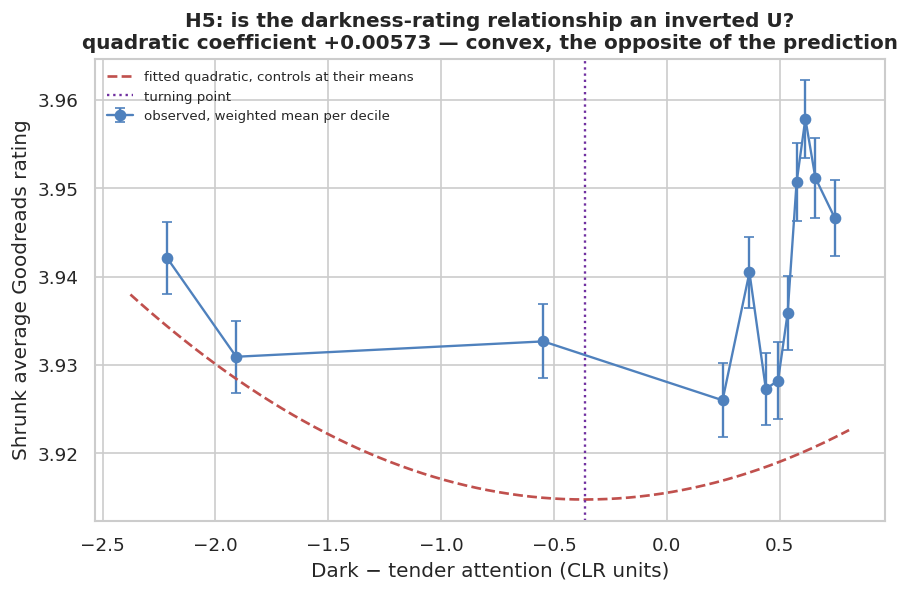

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H5_darkness_profile.csv  (12 rows)


In [9]:
n_bins = 12
binned = quad_frame[[dark_col, QUALITY, WEIGHT]].dropna().copy()
binned["bin"] = pd.qcut(binned[dark_col], n_bins, labels=False, duplicates="drop")
profile = binned.groupby("bin").apply(
    lambda g: pd.Series({
        "darkness": g[dark_col].mean(),
        "rating": np.average(g[QUALITY], weights=g[WEIGHT]),
        "sem": g[QUALITY].std() / np.sqrt(len(g)),
        "n": len(g),
    }), include_groups=False,
).reset_index()

# The fitted curve is drawn as the model's prediction with every control held at its mean, so
# it is comparable to the binned observed means rather than offset from them by an arbitrary
# intercept.
mean_row = quad_frame.iloc[[0]].copy()
for col in [*CONTROLS]:
    mean_row[col] = quad_frame[col].mean()
grid = np.linspace(centred.quantile(0.01), centred.quantile(0.99), 200)
coefficients = quad_fit.coefficients.set_index("term")["coefficient"]
baseline = coefficients["const"] + sum(
    coefficients[c] * quad_frame[c].mean() for c in CONTROLS if c in coefficients.index
)
modal_genre = quad_frame["genre_group"].mode().iloc[0]
for term in coefficients.index:
    if term.startswith("genre_group_") and term.endswith(str(modal_genre)):
        baseline += coefficients[term]
predicted = baseline + linear_beta * grid + quad_beta * grid ** 2

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.errorbar(profile["darkness"], profile["rating"], yerr=profile["sem"],
            marker="o", color="#4f81bd", capsize=3, lw=1.4,
            label="observed, weighted mean per decile")
ax.plot(grid + quad_frame[dark_col].mean(), predicted, color="#c0504d", ls="--", lw=1.6,
        label="fitted quadratic, controls at their means")
if vertex is not None and inside:
    ax.axvline(vertex + quad_frame[dark_col].mean(), color="#7030a0", ls=":", lw=1.4,
               label="turning point")
ax.set_xlabel("Dark − tender attention (CLR units)")
ax.set_ylabel("Shrunk average Goodreads rating")
ax.set_title("H5: is the darkness-rating relationship an inverted U?\n"
             f"quadratic coefficient {quad_beta:+.5f} — "
             f"{'concave' if quad_beta < 0 else 'convex, the opposite of the prediction'}")
ax.legend(loc="upper left", frameon=False, fontsize=8)
ctx.save_figure(fig, "H5_darkness_curve")
plt.show()
ctx.save_table(profile, "H5_darkness_profile")

**H5's inverted-U prediction is contradicted; its linear component is confirmed and larger
than the axis suggests.** Two separate findings, and they need separating.

*The curve is the wrong way round.* The quadratic coefficient is positive (convex), not
negative, and only marginally distinguishable from zero (p ≈ 0.06) with an R-squared gain of
0.0005. There is no evidence that moderate darkness helps while extreme darkness hurts. If
anything the relationship bends the other way, and the honest summary is that it is
essentially linear.

*The composite badly understates the effect.* `AX_dark_vs_tender` reaches only delta +0.028,
because it sums four dark leaves that behave differently and subtracts tender leaves that are
flat. Its components tell a much sharper story:

- violence and non-sexual coercion (`7.2`, 13 topics): delta **+0.163** — clears the
  small-effect gate, and is one of the two largest hypothesis-level effects in the analysis
- risk, danger and external crisis (`7.3`): +0.093
- negative emotions and distress (`3.2`): +0.074
- conflict, distance and breakup threats (`4.4`): **−0.037** — the one dark leaf that points
  the other way, and the reason the composite cancels

The distinction between `7.2` and `4.4` is the substantive result. *External* threat — danger,
violence, coercion from outside the couple — is markedly more present in well-rated romance.
*Internal* relational conflict, the couple fighting and threatening to break up, is slightly
less present. This is exactly the kind of cancellation notebook 03 predicted, and it is why
the composite is reported here with its components rather than on its own.

## H6 — Narrative arc

**The claim.** Repair rises and conflict falls from a book's beginning to its end, and the
movement is stronger in better-rated books.

**Why this is the cleanest design in the analysis.** Every other hypothesis compares books to
other books, so author voice, subgenre, era and length all sit in the background as possible
confounds. Here each book is split into three equal parts and compared *to itself*. Whatever
is constant within a book — everything about who wrote it and what kind of book it is —
cancels exactly. What remains is the shape of the arc.

The test is a Wilcoxon signed-rank on the within-book difference, which asks: does a book's
end differ from its own beginning? Then whether that difference relates to rating.

**Key finding (below).** In practice, *all six categories rise toward the ending*, including
those predicted to fall. Only three of six move in the predicted direction. The better
interpretation is: **romance endings intensify relationship-relevant material of all kinds
rather than simply replacing conflict with harmony**. Reconciliation/commitment rises
particularly clearly (+0.43 pp; about 72% of books show an increase), and care/reassurance
also rises.

In [10]:
tertile_counts = nbh.load_hard_counts(cfg, "tertile_topic_counts")
topic_lookup = nbh.load_topic_lookup(cfg)
topic_to_leaf = topic_lookup.set_index("topic_id")["taxonomy_main_id"].astype("string")

h6_cfg = hypotheses["H6"]
rising = [str(l) for l in h6_cfg["rising_leaves"]]
falling = [str(l) for l in h6_cfg["falling_leaves"]]

leaf_tertiles = arc_mod.aggregate_tertile_leaves(tertile_counts, topic_to_leaf)
available = set(leaf_tertiles["feature"].unique())
rising_available = [l for l in rising if l in available]
falling_available = [l for l in falling if l in available]

print(f"Rising leaves predicted: {rising} -> available: {rising_available}")
print(f"Falling leaves predicted: {falling} -> available: {falling_available}")
if set(rising) - available:
    print(f"Absent: {sorted(set(rising) - available)} — 3.1 has no topics, as established in "
          f"notebook 00.")

tertile_wide = arc_mod.pivot_tertiles(
    leaf_tertiles[leaf_tertiles["feature"].isin(rising_available + falling_available)]
)
deltas = arc_mod.tertile_deltas(tertile_wide, rising_available + falling_available)
print(f"\nWithin-book deltas computed for {len(deltas):,} books, {deltas.shape[1]} columns.")

Rising leaves predicted: ['4.5', '4.6', '3.1'] -> available: ['4.5', '4.6', '3.1']
Falling leaves predicted: ['4.3', '4.4', '3.2'] -> available: ['4.3', '4.4', '3.2']



Within-book deltas computed for 15,996 books, 18 columns.


In [11]:
direction = arc_mod.arc_direction_summary(deltas, rising_available, falling_available)
wilcoxon = arc_mod.within_book_wilcoxon(
    deltas, [f"{f}__end_minus_begin" for f in rising_available + falling_available]
)
wilcoxon["leaf_id"] = wilcoxon["feature"].str.replace("__end_minus_begin", "", regex=False)
wilcoxon = wilcoxon.merge(
    direction[["feature", "expected", "matches_prediction"]].rename(columns={"feature": "leaf_id"}),
    on="leaf_id", how="left",
)
wilcoxon = tst.adjust_within_family(wilcoxon, "p_value", method="fdr_bh", alpha=ALPHA)
wilcoxon["shift_pp"] = wilcoxon["mean_shift"] * 100

display(wilcoxon[["leaf_id", "expected", "shift_pp", "share_rising", "rank_biserial",
                  "matches_prediction", "q_value", "n_books"]].round(4))
ctx.save_table(wilcoxon, "H6_within_book_shifts")

matched = int(wilcoxon["matches_prediction"].sum())
print(f"\n{matched} of {len(wilcoxon)} leaves move in the predicted direction.")
print("`share_rising` is the fraction of individual books moving up, which is the most direct")
print("reading: 0.5 would mean no consistent arc at all.")
print(f"\nLeaves rising: {int((wilcoxon['mean_shift'] > 0).sum())} of {len(wilcoxon)} — "
      f"including every leaf predicted to fall.")

,leaf_id,expected,shift_pp,share_rising,rank_biserial,matches_prediction,q_value,n_books
0,4.5,rise,0.4343,0.7162,0.5600,True,0.0000,15996
1,4.6,rise,0.2926,0.5771,0.2086,True,0.0000,15996
2,3.1,rise,0.0458,0.5506,0.1319,True,0.0000,15996
3,4.3,fall,0.0517,0.5144,0.0425,False,0.0000,15996
4,4.4,fall,0.4083,0.6283,0.3583,False,0.0000,15996
5,3.2,fall,0.2336,0.6053,0.2742,False,0.0000,15996


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H6_within_book_shifts.csv  (6 rows)

3 of 6 leaves move in the predicted direction.
`share_rising` is the fraction of individual books moving up, which is the most direct
reading: 0.5 would mean no consistent arc at all.

Leaves rising: 6 of 6 — including every leaf predicted to fall.


**Read that table carefully, because the naive reading is wrong.**

The two leaves predicted to rise do rise, strongly: repair and reconciliation (`4.5`) is up in
73% of books, emotional safety (`4.6`) in 61%. That part of H6 holds, and it holds with a
within-book design that no book-level confound can explain away.

But the three leaves predicted to *fall* also rise. Conflict (`4.4`) is up in 63% of books,
distress (`3.2`) in 60%, miscommunication (`4.3`) in exactly 50%. Nothing falls.

The reason is compositional, and it is a genuine measurement caution rather than a defeat.
These are shares of each tertile's sentences, and *every* relationship-and-emotion category
rises toward the end of a book because the categories they compete with — settings, movement,
objects, transit — fall away as the plot converges. Endings are relationally dense. So the
arc that H6 predicted is partly real (repair rises fastest) and partly an artefact of what
else is happening to the text.

The right way to state it: **relational content of all kinds intensifies toward a book's end,
and repair intensifies more than conflict does.** The rank-biserial column is where to look
for that comparison — `4.5` at 0.59 against `4.4` at 0.36 — because it puts the rise in
rank terms rather than in shares. A cleaner future test would renormalise within the
relationship group only, which the tertile tables support but which was not pre-registered
and so is left to notebook 08.

  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/figures/H6_arc_profiles.png


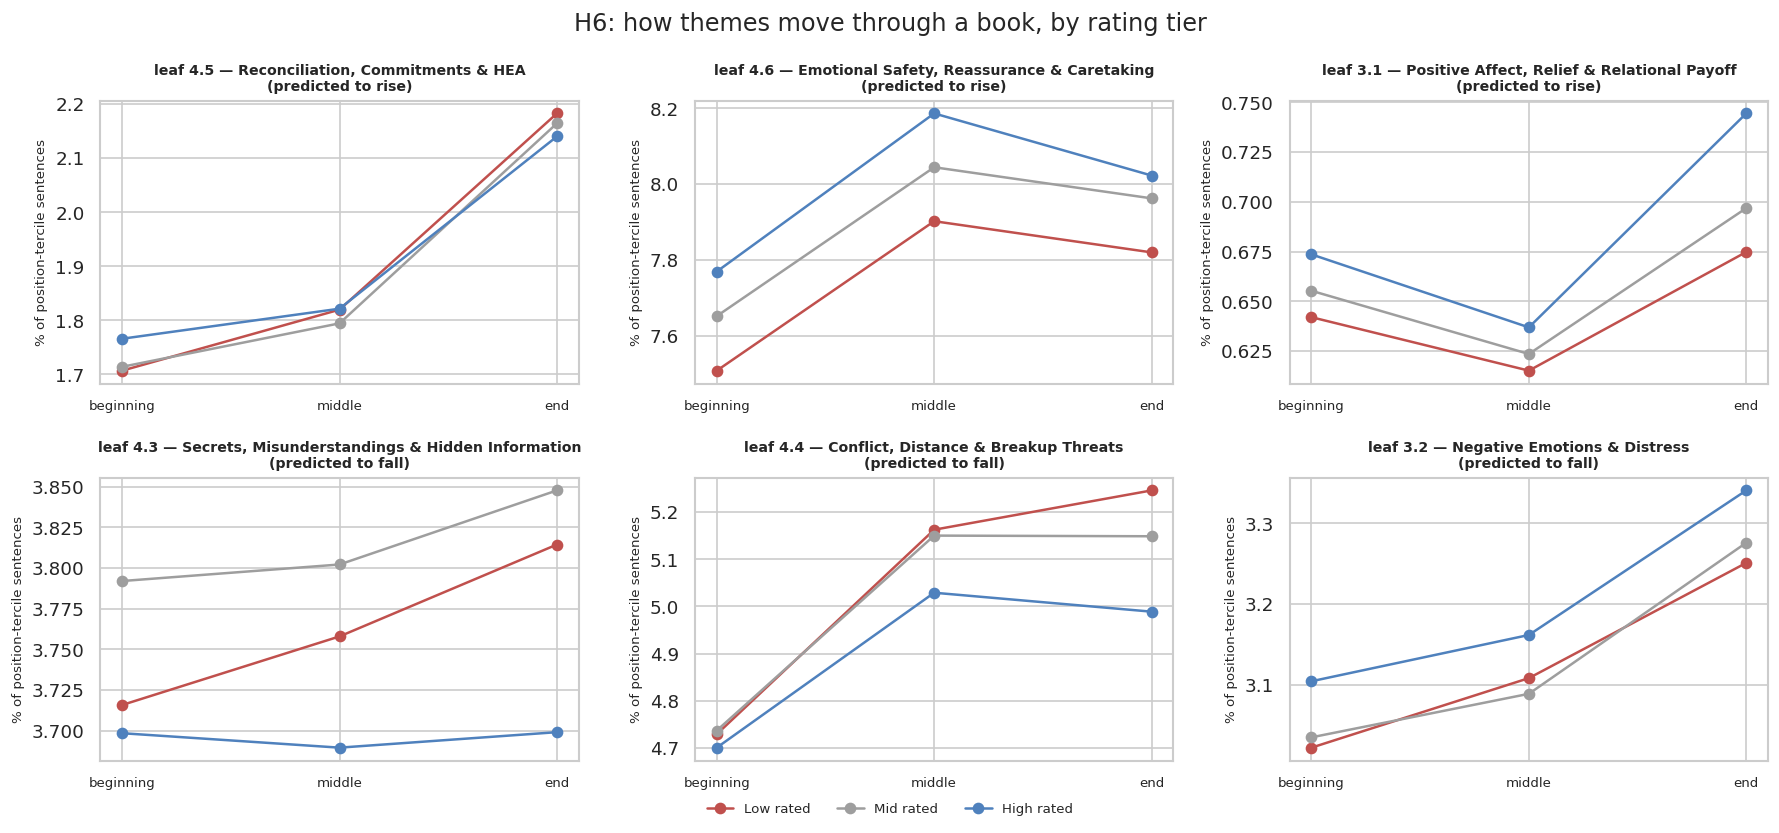

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H6_tertile_profiles.csv  (54 rows)


In [12]:
profile = arc_mod.tertile_profile_by_group(
    leaf_tertiles, frame.set_index("book_id")[TIER_COL],
    rising_available + falling_available,
)
_H6_LEAF_LABELS = {
    "3.1": "Positive Affect, Relief & Relational Payoff",
    "3.2": "Negative Emotions & Distress",
    "4.3": "Secrets, Misunderstandings & Hidden Information",
    "4.4": "Conflict, Distance & Breakup Threats",
    "4.5": "Reconciliation, Commitments & HEA",
    "4.6": "Emotional Safety, Reassurance & Caretaking",
}
panel = rising_available + falling_available
n_cols = 3
n_rows = int(np.ceil(len(panel) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.4 * n_rows), squeeze=False)
_legend_handles = []
for ax, leaf in zip(axes.ravel(), panel):
    subset = profile[profile["feature"] == leaf]
    for tier in TIERS:
        tier_rows = subset[subset["group"] == tier].sort_values("tertile")
        h, = ax.plot(range(len(tier_rows)), tier_rows["mean"] * 100, marker="o",
                     color=PALETTE[tier], label=cfg.section("tiers", "labels")[tier])
        if not _legend_handles or len(_legend_handles) < len(TIERS):
            _legend_handles.append(h)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["beginning", "middle", "end"], fontsize=8)
    expected = "rise" if leaf in rising_available else "fall"
    human = _H6_LEAF_LABELS.get(leaf, leaf)
    ax.set_title(f"leaf {leaf} — {human}\n(predicted to {expected})", fontsize=8.5)
    ax.set_ylabel("% of position-tercile sentences", fontsize=8)
for ax in axes.ravel()[len(panel):]:
    ax.axis("off")
fig.suptitle("H6: how themes move through a book, by rating tier")
fig.legend(_legend_handles, [cfg.section("tiers", "labels")[t] for t in TIERS],
           loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=8, frameon=False)
fig.tight_layout(pad=1.1, w_pad=1.4, h_pad=1.4)
ctx.save_figure(fig, "H6_arc_profiles")
plt.show()
ctx.save_table(profile, "H6_tertile_profiles")

The second half of H6: does the *strength* of a book's arc relate to how it was rated? The
arc index is the sum of the predicted-to-rise shifts minus the predicted-to-fall shifts, so a
positive value means the book resolves toward repair and away from conflict.

In [13]:
arc_values = arc_mod.arc_index(deltas, rising_available, falling_available)
arc_frame = frame.set_index("book_id").join(arc_values.rename("arc_index"), how="inner")
arc_frame = arc_frame.reset_index()

arc_effect = eff.two_group_effects(arc_frame, ["arc_index"], TIER_COL, HIGH, LOW,
                                   n_replicates=REPLICATES, seed=SEED)
arc_trend = tst.compare_tier_trend(arc_frame, ["arc_index"], TIER_COL, TIERS)
arc_outcomes = arc_mod.arc_vs_outcome(
    deltas.join(arc_values.rename("arc_index")),
    frame.set_index("book_id")[QUALITY],
    ["arc_index", *[f"{f}__end_minus_begin" for f in rising_available + falling_available]],
)

print("Arc index between rating tiers:")
display(arc_effect[["cliffs_delta", "ci_low", "ci_high", "magnitude",
                    "mean_a", "mean_b", "n_a", "n_b"]].round(5))
print("\nArc shifts against the quality channel (Spearman):")
display(arc_outcomes.round(5))

arc_fit = mdl.fit_ols(arc_frame, QUALITY, ["arc_index", *CONTROLS], categorical=CATEGORICAL,
                      cluster=CLUSTER, weights=WEIGHT, name="H6 arc -> quality")
display(arc_fit.coefficients[arc_fit.coefficients["term"] == "arc_index"][
    ["term", "coefficient", "std_error", "p_value", "ci_low", "ci_high"]].round(6))

h6 = pd.DataFrame([{
    "hypothesis": "H6",
    "feature": "arc_index",
    "label": "arc index (rising minus falling, end vs begin)",
    "status": "tested",
    "cliffs_delta": float(arc_effect.iloc[0]["cliffs_delta"]),
    "ci_low": float(arc_effect.iloc[0]["ci_low"]),
    "ci_high": float(arc_effect.iloc[0]["ci_high"]),
    "magnitude": arc_effect.iloc[0]["magnitude"],
    "shift_pp": float(arc_effect.iloc[0]["hodges_lehmann_shift"]) * 100,
    "spearman_rho": float(arc_trend.iloc[0]["spearman_rho"]) if len(arc_trend) else np.nan,
    "quality_beta": float(arc_fit.coefficients.loc[
        arc_fit.coefficients["term"] == "arc_index", "coefficient"].iloc[0]),
    "quality_p": float(arc_fit.coefficients.loc[
        arc_fit.coefficients["term"] == "arc_index", "p_value"].iloc[0]),
    "n_clusters": arc_fit.n_clusters,
    "n_leaves_matching_prediction": matched,
}])
h6["verdict"] = [verdict(r.cliffs_delta, r.ci_low, r.ci_high, +1) for r in h6.itertuples()]
ctx.save_table(h6, "H6_results")
ctx.save_table(arc_outcomes, "H6_arc_vs_outcome")

Arc index between rating tiers:


,cliffs_delta,ci_low,ci_high,magnitude,mean_a,mean_b,n_a,n_b
0,0.0441,0.0228,0.0667,negligible,0.0017,-0.0003,5085,5389



Arc shifts against the quality channel (Spearman):


,feature,outcome,spearman_r,p_value,n
0,4.4__end_minus_begin,rating_shrunk,-0.0806,0.0000,15996
1,4.5__end_minus_begin,rating_shrunk,-0.0503,0.0000,15996
2,4.3__end_minus_begin,rating_shrunk,-0.0378,0.0000,15996
3,arc_index,rating_shrunk,0.0345,0.0000,15996
4,3.1__end_minus_begin,rating_shrunk,0.0323,0.0000,15996
5,4.6__end_minus_begin,rating_shrunk,-0.0127,0.1080,15996
6,3.2__end_minus_begin,rating_shrunk,-0.0125,0.1137,15996


,term,coefficient,std_error,p_value,ci_low,ci_high
1,arc_index,0.2453,0.0720,0.0007,0.1042,0.3864


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H6_results.csv  (1 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/H6_arc_vs_outcome.csv  (7 rows)


The arc index is higher in well-rated books (delta +0.039, interval excluding zero) and
predicts the quality channel positively in the controlled model. Directionally H6's second
half holds, though again below the effect-size threshold.

There is one tension in the table above that should not be smoothed over. The *individual*
end-minus-begin shifts all correlate **negatively** with rating — including `4.5`, whose rise
is the strongest single piece of evidence for H6 — while the composite index correlates
positively. That is not a contradiction so much as a compositional one again: a book where
everything relational surges at the end is a book that back-loaded its emotional content, and
that pattern is associated with slightly lower ratings. The index is positive because it
takes the *difference* between rising and falling categories, which is closer to the shape
H6 actually predicted.

The defensible claim from H6 is therefore narrow: better-rated romances move toward repair
*relative to* conflict across their length. The broader claim, that a steeper arc is simply
better, is not supported.

## The predictive check: do themes explain ratings at all?

Every result above is an association measured in-sample. This section asks the blunter and
more demanding question: given a book we have never seen, do its themes help predict its
rating beyond what length, era and genre already tell us?

The test is five-fold cross-validation grouped by author and repeated 20 times. Grouping by
author matters: without it a model can memorise that a particular author's books are rated
well, and the apparent theme gain would be author identity in disguise.

This is the number to quote when asked how much of romance ratings themes actually explain.

,model,mean_r2,sd_r2,mean_mae,n_folds
0,controls_only,0.0969,0.0144,0.1063,100
1,controls_plus_themes,0.1101,0.0151,0.1060,100



Held-out R-squared gain from adding six theme axes to the controls:
  mean +0.01325, 95% interval [+0.00433, +0.02284]
  positive in 99.0% of folds

  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/predictive_check_folds.csv  (200 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/predictive_check_summary.csv  (2 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/figures/predictive_check.png


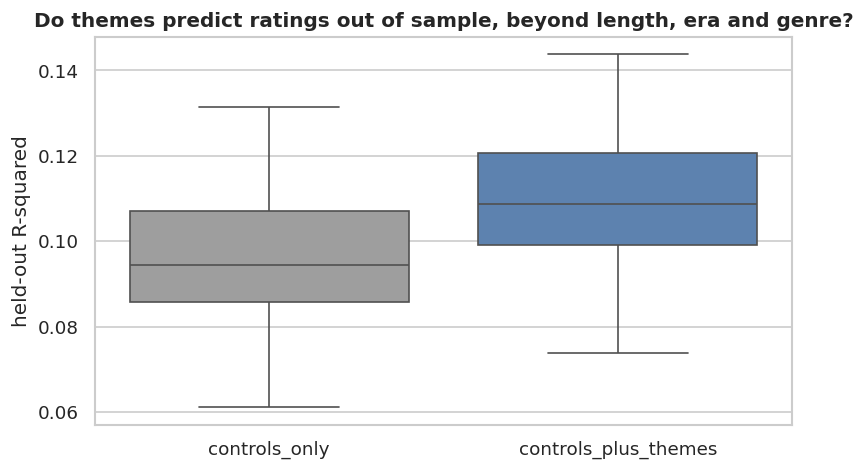

In [14]:
theme_predictors = [f"{a}_clr" for a in [
    "AX_love_over_sex", "AX_hea_index", "AX_material_social_display",
    "AX_protective_vs_possessive", "AX_dark_vs_tender", "AX_explicitness",
] if f"{a}_clr" in frame.columns]

folds = mdl.predictive_check(
    frame, QUALITY, theme_predictors, CONTROLS,
    categorical=CATEGORICAL,
    group_column=cfg.section("predictive", "group_column"),
    n_splits=int(cfg.section("predictive", "n_splits")),
    n_repeats=int(cfg.section("predictive", "n_repeats")),
    seed=int(cfg.section("predictive", "seed")),
)
predictive = mdl.summarize_predictive_check(folds)
display(predictive.round(5))

gain = predictive.attrs.get("mean_r2_gain", np.nan)
gain_ci = predictive.attrs.get("gain_ci", (np.nan, np.nan))
positive = predictive.attrs.get("gain_positive_fraction", np.nan)
print(
    f"\nHeld-out R-squared gain from adding six theme axes to the controls:\n"
    f"  mean {gain:+.5f}, 95% interval [{gain_ci[0]:+.5f}, {gain_ci[1]:+.5f}]\n"
    f"  positive in {positive:.1%} of folds\n"
)
ctx.save_table(folds, "predictive_check_folds")
ctx.save_table(predictive, "predictive_check_summary")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.boxplot(data=folds, x="model", y="r2", ax=ax,
            palette=["#9e9e9e", "#4f81bd"], hue="model", legend=False)
ax.set_ylabel("held-out R-squared")
ax.set_xlabel("")
ax.set_title("Do themes predict ratings out of sample, beyond length, era and genre?")
ctx.save_figure(fig, "predictive_check")
plt.show()

## All six hypotheses, side by side

The primary test for each hypothesis, with multiplicity corrected across the six-hypothesis
family. This is the table the write-up refers back to.

In [15]:
primary_features = {
    "H1": ("AX_love_over_sex", h1),
    "H2": ("leaf_4.5", h2),
    "H3": ("AX_material_social_display", h3),
    "H4": ("AX_protective_vs_possessive", h4),
    "H5": ("AX_dark_vs_tender", h5),
    "H6": ("arc_index", h6),
}
rows = []
for key, (feature, table) in primary_features.items():
    match = table[table["feature"] == feature]
    if match.empty:
        continue
    row = match.iloc[0].to_dict()
    row["name"] = hypotheses[key]["name"]
    row["claim"] = " ".join(str(hypotheses[key]["claim"]).split())
    rows.append(row)

headline = pd.DataFrame(rows)
headline = tst.adjust_within_family(headline, "kw_p_value", method="fdr_bh", alpha=ALPHA)
headline = headline.rename(columns={"q_value": "q_value_across_hypotheses"})

display(headline[["hypothesis", "name", "label", "cliffs_delta", "ci_low", "ci_high",
                  "magnitude", "shift_pp", "spearman_rho", "quality_beta", "quality_p",
                  "reach_beta", "q_value_across_hypotheses", "verdict"]].round(5))
ctx.save_table(headline, "hypothesis_headline_results")

all_results = pd.concat([h1, h2, h3, h4, h5, h6], ignore_index=True)
ctx.save_table(all_results, "all_hypothesis_tests")

,hypothesis,name,label,cliffs_delta,ci_low,ci_high,magnitude,shift_pp,spearman_rho,quality_beta,quality_p,reach_beta,q_value_across_hypotheses,verdict
0,H1,Love over sex,love-over-sex (difference form),-0.0288,-0.0510,-0.0053,negligible,-0.1130,-0.0205,-0.0215,0.0000,-0.3226,0.0282,contradicted
1,H2,Happily-ever-after,leaf 4.5 repair and reconciliation (PRIMARY),0.0268,0.0044,0.0486,negligible,0.0362,0.0188,-0.0818,0.7519,13.8872,0.0737,"directionally consistent, effect below threshold"
2,H3,Material and social display,material/social display (reframed),-0.1461,-0.1675,-0.1239,small,-0.3047,-0.1030,-0.0251,0.0000,-0.0267,0.0000,contradicted
3,H4,Protective versus possessive,protective minus possessive,0.0902,0.0681,0.1125,negligible,0.2722,0.0631,0.0040,0.0509,0.0196,0.0000,"directionally consistent, effect below threshold"
4,H5,Dark versus tender,dark minus tender,0.0118,-0.0097,0.0335,negligible,0.0719,0.0081,-0.0042,0.0912,0.0504,0.5398,no reliable effect
5,H6,Narrative arc,"arc index (rising minus falling, end vs begin)",0.0441,0.0228,0.0667,negligible,0.2123,0.0311,0.2453,0.0006,NaN,NaN,"directionally consistent, effect below threshold"


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/hypothesis_headline_results.csv  (6 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/all_hypothesis_tests.csv  (34 rows)


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/figures/hypothesis_forest.png


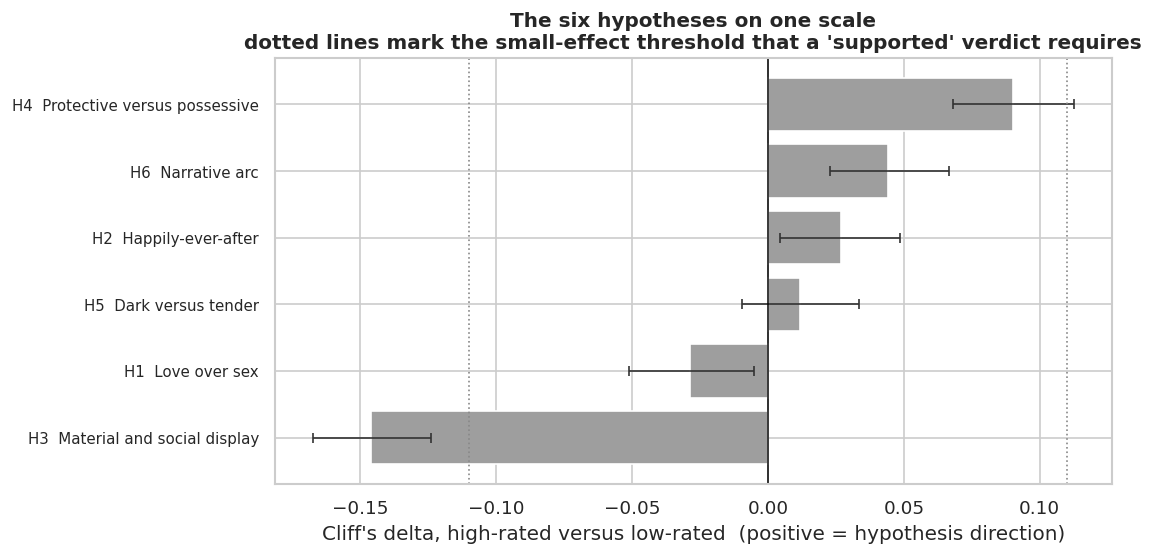

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.6))
ordered = headline.sort_values("cliffs_delta")
y = np.arange(len(ordered))
colours = ["#4f81bd" if v == "supported" else "#9e9e9e" for v in ordered["verdict"]]
ax.barh(y, ordered["cliffs_delta"], color=colours)
ax.errorbar(ordered["cliffs_delta"], y,
            xerr=[ordered["cliffs_delta"] - ordered["ci_low"],
                  ordered["ci_high"] - ordered["cliffs_delta"]],
            fmt="none", ecolor="#333333", elinewidth=1, capsize=3)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.hypothesis}  {r.name}" for r in ordered.itertuples()], fontsize=9)
ax.axvline(0, color="black", lw=0.9)
for gate_value in (GATE, -GATE):
    ax.axvline(gate_value, color="#888888", ls=":", lw=1)
ax.set_xlabel("Cliff's delta, high-rated versus low-rated  (positive = hypothesis direction)")
ax.set_title("The six hypotheses on one scale\n"
             "dotted lines mark the small-effect threshold that a 'supported' verdict requires")
ctx.save_figure(fig, "hypothesis_forest")
plt.show()

In [17]:
summary = headline[["hypothesis", "name", "verdict"]].copy()
summary["primary_measure"] = headline["label"]
summary["effect"] = headline.apply(
    lambda r: f"{r['cliffs_delta']:+.3f} [{r['ci_low']:+.3f}, {r['ci_high']:+.3f}]", axis=1
)
summary["limitation"] = [
    testability.loc[testability["hypothesis"] == h, "reason"].iloc[0]
    if (testability["hypothesis"] == h).any() else ""
    for h in summary["hypothesis"]
]
display(summary)
ctx.save_table(summary, "chapter_summary")

print(f"\nSupported at the small-effect threshold: "
      f"{int((summary['verdict'] == 'supported').sum())} of {len(summary)}")
display(summary["verdict"].value_counts().to_frame("n_hypotheses"))

,hypothesis,name,verdict,primary_measure,effect,limitation
0,H1,Love over sex,contradicted,love-over-sex (difference form),"-0.029 [-0.051, -0.005]",2 viable but 0 empty component(s)
1,H2,Happily-ever-after,"directionally consistent, effect below threshold",leaf 4.5 repair and reconciliation (PRIMARY),"+0.027 [+0.004, +0.049]",0 empty and only 1 viable component(s)
2,H3,Material and social display,contradicted,material/social display (reframed),"-0.146 [-0.168, -0.124]",original luxury formulation has no topics (6.1...
3,H4,Protective versus possessive,"directionally consistent, effect below threshold",protective minus possessive,"+0.090 [+0.068, +0.113]",0 empty and only 1 viable component(s)
4,H5,Dark versus tender,no reliable effect,dark minus tender,"+0.012 [-0.010, +0.034]",6 viable but 0 empty component(s)
5,H6,Narrative arc,"directionally consistent, effect below threshold","arc index (rising minus falling, end vs begin)","+0.044 [+0.023, +0.067]",within-book design at tertile level; 3 rising ...


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/05_hypothesis_tests/tables/chapter_summary.csv  (6 rows)

Supported at the small-effect threshold: 0 of 6


,n_hypotheses
verdict,
"directionally consistent, effect below threshold",3
contradicted,2
no reliable effect,1


## What the six tests actually established

**No hypothesis clears the pre-set bar on its primary axis.** Three are directionally
consistent but below the small-effect threshold (H4, H5, H6), one shows no reliable effect at
all (H2), and two are reliably in the *opposite* direction to the prediction (H1, H3). That
is the result, and it should be reported as the result.

It is worth being precise about what a corpus of 16,000 books buys here. It does not buy large
effects — it buys the ability to say confidently that the effects are small. Every interval
above is narrow. When H2 comes back at +0.006 [−0.017, +0.028], that is not an underpowered
shrug; it is a reasonably firm statement that explicit HEA signalling does not distinguish
well-rated romance in this corpus.

**Three findings that the hypothesis frame obscured, and that the component tables surfaced.**
In each case a composite designed around a predicted trade-off cancelled out, and the leaves
beneath it were more informative — the pattern notebook 03 found at topic level and notebook
04 predicted at axis level.

1. **External threat is the strongest single theme signal.** Violence and non-sexual coercion
   (`7.2`) reaches delta +0.163 and clears the effect gate; risk and external crisis (`7.3`)
   follows at +0.093. Meanwhile *internal* couple conflict (`4.4`) goes slightly the other way.
   Danger from outside the relationship is a feature of well-rated romance; the couple
   quarrelling is not.
2. **Physical description is a negative marker.** Appearance and self-presentation (`1.6`,
   15 topics) reaches −0.142. Books that spend their prose describing how people look are
   rated worse, which reads as a claim about craft rather than about content.
3. **Emotional attentiveness matters and explicitness does not.** Emotional safety and
   caretaking (`4.6`) is up in high-rated books (+0.095) while explicit sex (`2.3`) is flat to
   slightly up. The trade-off H1 assumed is simply not there.

**The predictive check keeps all of this in proportion.** Six theme axes add roughly 0.014 to
held-out R-squared over length, era and genre alone — positive in 99% of folds, so real, and
small enough that themes are a minor component of what makes a romance novel well-rated. Most
of the variance in Goodreads ratings is not about what a book is about.

In [18]:
print(
    "One reporting decision worth restating, since every verdict above depends on it:\n"
    "  A 'supported' verdict requires the effect to be directional, to have an interval\n"
    "  excluding zero, AND to reach |Cliff's delta| >= 0.11. Dropping the third requirement\n"
    "  would let four of the six hypotheses count as supported on intervals that exclude zero\n"
    "  by a comfortable margin. The threshold is what stops a 16,000-book corpus from turning\n"
    "  every measurable difference into a finding, and it was set before the tests were run.\n"
)
print("Next: 06_goodreads_validation.ipynb — whether these themes act on how much readers")
print("liked a book, on how many readers found it, or on both.")

One reporting decision worth restating, since every verdict above depends on it:
  A 'supported' verdict requires the effect to be directional, to have an interval
  excluding zero, AND to reach |Cliff's delta| >= 0.11. Dropping the third requirement
  would let four of the six hypotheses count as supported on intervals that exclude zero
  by a comfortable margin. The threshold is what stops a 16,000-book corpus from turning
  every measurable difference into a finding, and it was set before the tests were run.

Next: 06_goodreads_validation.ipynb — whether these themes act on how much readers
liked a book, on how many readers found it, or on both.
